In [57]:
import pandas as pd
import numpy as np
import trackpy as tp
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt

### Enter 1 for brownian, 0 for lab data
---
# Lab data

In [ ]:
# For a choice of lab data or simulated data. 
inputflag = input("1 for brownian, 0 for lab data")
if inputflag == "1":
    df = pd.read_csv("results_output_100frames_10secs.csv")
    
    print(df.head())

    positions_df = pd.read_csv("results_output_100frames_10secs.csv")



    #### UNCOMMENT TO REMOVE THE LACK OF TRACKING / VIDEO STOPPING

    positions_df=positions_df[positions_df["frame"]<120]
    

        ####
        # positions_df=positions_df[positions_df["index"]<20]
#Tp link is a function that links the positions of particles across frames to create trajectories. It takes into account the search range (how far a particle can move between frames), memory (how many frames a particle can disappear and reappear), and adaptive parameters to handle varying particle densities. The output is a DataFrame with an additional "particle" column that assigns a unique ID to each trajectory.
    trajectories = tp.link(positions_df,search_range=5,memory=5,adaptive_stop=0.5,adaptive_step=0.95,threshold=4)
elif inputflag == "0":
    df = pd.read_csv("positions_old.csv")

    print(df.head())

    positions_df = pd.read_csv("positions_old.csv")
    positions_df = positions_df[positions_df["frame"] < 100]  # Filter to first 100 frames

    trajectories = tp.link(positions_df, search_range=5, memory=5) # 5 frames
    trajectories = tp.filter_stubs(trajectories, threshold=5)
    print(positions_df["frame"].unique())
    trajectories.head()
    positions_df["frame"].max()

Frame 99: 842 trajectories present.
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71.
 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89.
 90. 91. 92. 93. 94. 95. 96. 97. 98. 99.]


## Simulation data - Uncomment for brownian

In [ ]:
#### UNCOMMENT TO REMOVE THE LACK OF TRACKING / VIDEO STOPPING

positions_df=positions_df[positions_df["frame"]<120]


####
#Positions_df=positions_df[positions_df["index"]<20]
trajectories = tp.link(positions_df,search_range=5,memory=5,adaptive_stop=0.5,adaptive_step=0.95)
print(positions_df["frame"].unique())
trajectories.head()
display(positions_df)
positions_df["frame"].max()

Frame 99: 842 trajectories present.
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71.
 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89.
 90. 91. 92. 93. 94. 95. 96. 97. 98. 99.]


,index,frame,x,y
0,1,0.0,279.000000,0.500000
1,2,0.0,10.000000,3.000000
2,3,0.0,297.500000,3.000000
3,4,0.0,53.000000,4.500000
4,5,0.0,274.333333,4.666667
...,...,...,...,...
85326,85327,99.0,150.000000,317.000000
85327,85328,99.0,161.666667,317.333333
85328,85329,99.0,1.000000,318.000000
85329,85330,99.0,178.000000,318.000000


99.0

In [ ]:
#Display the DataFrame sorted by "index" and "frame"- index is particle ID
df = df.sort_values(["index", "frame"])
display(df)

,index,frame,x,y
0,1,0.0,279.000000,0.500000
1,2,0.0,10.000000,3.000000
2,3,0.0,297.500000,3.000000
3,4,0.0,53.000000,4.500000
4,5,0.0,274.333333,4.666667
...,...,...,...,...
168624,168625,199.0,193.000000,315.000000
168625,168626,199.0,32.000000,316.500000
168626,168627,199.0,58.000000,316.000000
168627,168628,199.0,171.500000,316.000000


In [61]:
# remove very short tracks
traj = trajectories.groupby("particle").filter(lambda g: len(g) > 5)
traj.groupby("particle").size().describe()
display(traj)
print(traj["frame"].nunique())

,index,frame,x,y,particle
577,578,0,96.000000,213.000000,1
578,579,0,168.500000,213.000000,2
579,580,0,10.000000,214.000000,3
580,581,0,180.500000,214.000000,4
581,582,0,49.666667,215.333333,5
...,...,...,...,...,...
84772,84773,99,108.000000,128.000000,2055
84773,84774,99,42.333333,129.333333,843
84775,84776,99,98.000000,129.000000,2038
84751,84752,99,55.500000,118.000000,865


100


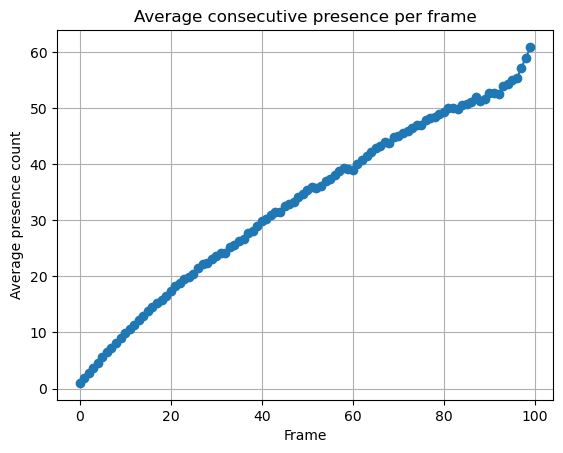

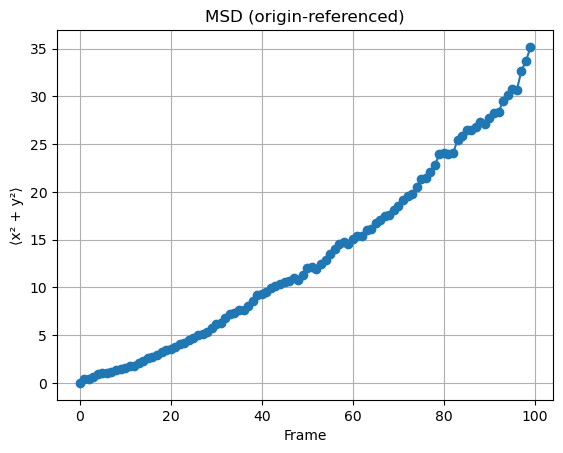

200

60.87176165803109


In [ ]:
# MSD from origin (single-cell, dataframe-based)
# Computes the mean squared displacement from the initial position for each particle, averaged over all particles at each frame. Resets if a particle disappears and reappears (gaps > 3 frames).
def compute_msd(df):
    df = df.sort_values(["particle","frame"]).copy()
    df["x0"] = df.groupby("particle")["x"].transform("first"); df["y0"] = df.groupby("particle")["y"].transform("first")
    df["x_zero"] = df["x"] - df["x0"]; df["y_zero"] = df["y"] - df["y0"]
    df["r2"] = df["x_zero"]**2 + df["y_zero"]**2
    return df.groupby("frame")["r2"].mean().reset_index(name="msd")
# count consecutive presence per particle (resets after gaps)

def add_presence_count(df):
    df = df.sort_values(["particle","frame"]).copy()
    
    # detect frame gaps within each particle trajectory
    df["frame_diff"] = df.groupby("particle")["frame"].diff()
    
    # new segment if gap > 1 or first occurrence
    df["new_segment"] = (df["frame_diff"].isna()) | (df["frame_diff"] > 3)
    
    # assign segment IDs per particle
    df["segment_id"] = df.groupby("particle")["new_segment"].cumsum()
    
    # cumulative count within each segment
    df["presence_count"] = df.groupby(["particle","segment_id"]).cumcount() + 1
    
    return df.drop(columns=["frame_diff","new_segment","segment_id"])
# average presence count per frame

def average_presence_per_frame(df):
    return df.groupby("frame")["presence_count"].mean().reset_index(name="avg_presence")
msd = compute_msd(traj)
msd.head()
traj = add_presence_count(traj)
avg_presence = average_presence_per_frame(traj)

plt.plot(avg_presence["frame"], avg_presence["avg_presence"], marker="o")
plt.xlabel("Frame"); plt.ylabel("Average presence count")
plt.title("Average consecutive presence per frame")
plt.grid(True); plt.show()


plt.plot(msd["frame"], msd["msd"], marker="o")
plt.xlabel("Frame"); plt.ylabel("⟨x² + y²⟩"); plt.title("MSD (origin-referenced)")
plt.grid(True); plt.show()
display(df["frame"].nunique())
print(max(avg_presence["avg_presence"]))

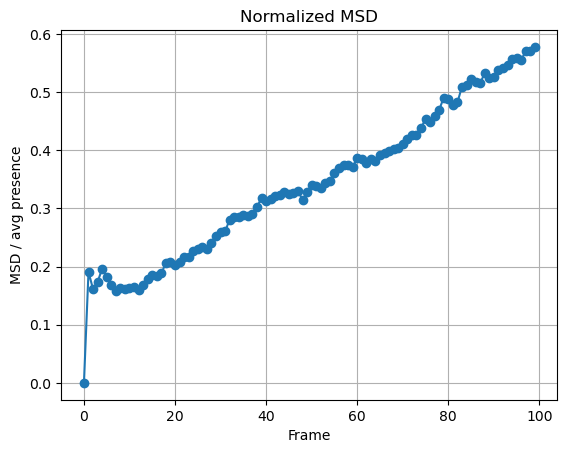

,frame,msd
0,0,0.000000
1,1,0.367392
2,2,0.459663
3,3,0.648817
4,4,0.912001
...,...,...
95,95,30.722673
96,96,30.644057
97,97,32.677266
98,98,33.658093


In [ ]:
# Investigating normalised MSD. Normalizing the MSD by the average presence count per frame can help us understand how the MSD evolves relative to how long particles have been present. This can reveal whether particles that are present for longer times tend to have higher or lower MSDs, and can help identify any time-dependent behaviors in the particle motion.
msd = compute_msd(traj)
msd.head()
# merge on frame to ensure alignment
merged = msd.merge(avg_presence, on="frame", how="inner")

# avoid division by zero
merged = merged[merged["avg_presence"] > 0]

# compute normalized MSD
merged["msd_norm"] = merged["msd"] / merged["avg_presence"]
plt.plot(merged["frame"], merged["msd_norm"], marker="o")
plt.xlabel("Frame"); plt.ylabel("MSD / avg presence")
plt.title("Normalized MSD")
plt.grid(True); plt.show()
display(msd)

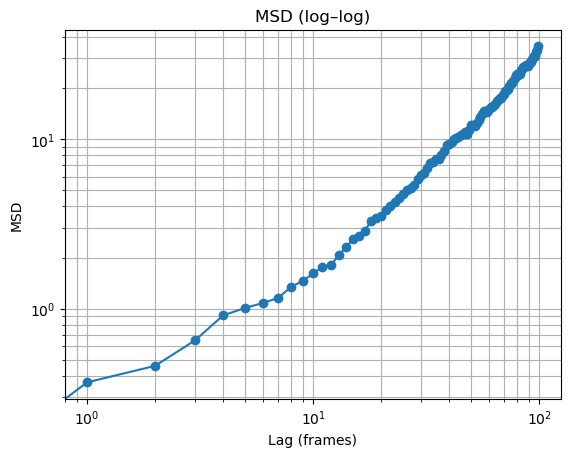

In [ ]:
# Log plot, apparently sometimes useful for identifying scaling behavior (e.g., diffusive vs subdiffusive). If the MSD scales as a power law with time, this will appear as a straight line on a log–log plot, and the slope can give insights into the type of motion.
plt.figure()
plt.loglog(msd["frame"], msd["msd"], marker="o")
plt.xlabel("Lag (frames)")
plt.ylabel("MSD")
plt.title("MSD (log–log)")
plt.grid(True, which="both")
plt.show()

In [ ]:

# Zero trajectories - shifts each particle's trajectory so it starts at the origin (0,0). This allows us to analyze the shape of trajectories without being influenced by their initial positions. The function sorts the DataFrame by "particle" and "frame", then computes the initial position for each particle and creates new columns for the relative x and y positions.
def zero_trajectories(df):
    df = df.sort_values(["particle", "frame"])

    # subtract initial position per particle
    df[["x0", "y0"]] = df.groupby("particle")[["x", "y"]].transform("first")
    df["x_rel"] = df["x"] - df["x0"]
    df["y_rel"] = df["y"] - df["y0"]

    return df

traj_rel = zero_trajectories(trajectories)

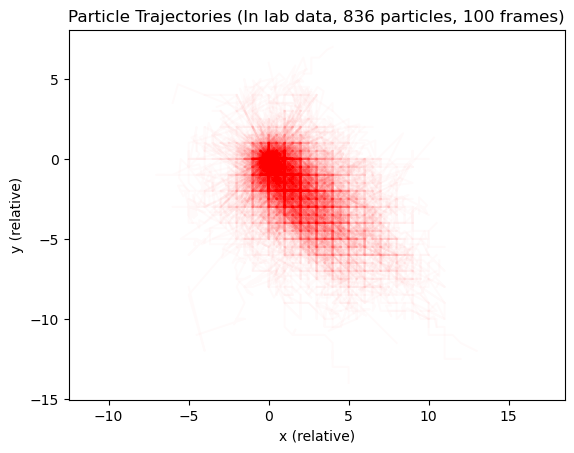

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
# Trajectory plot - shows the path of each particle over time, starting from the origin (0,0).
plt.figure()
# pid is particle id
for pid, group in traj_rel.groupby("particle"):
    plt.plot(group["x_rel"], group["y_rel"], alpha=0.02, color = "red")

# PLOTS 
plt.xlabel("x (relative)")
plt.ylabel("y (relative)")
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.title("Particle Trajectories (In lab data, 836 particles, 100 frames)")
plt.axis("equal")
plt.show()
plt.tight_layout()

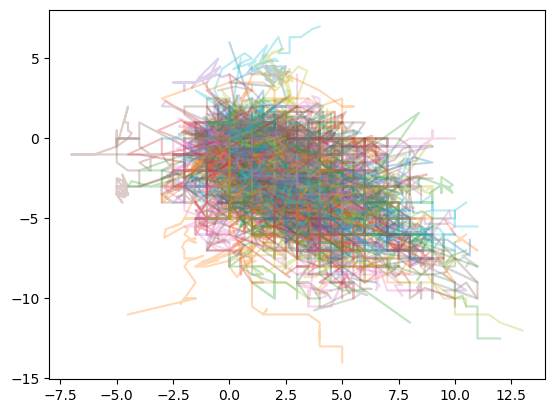

In [ ]:
# Trajectory density plot - shows where particles have moved and how
valid = traj_rel.groupby("particle").filter(lambda g: len(g) > 50)
group = group.interpolate()
for pid, g in valid.groupby("particle"):
    plt.plot(g["x_rel"], g["y_rel"], alpha=0.3)

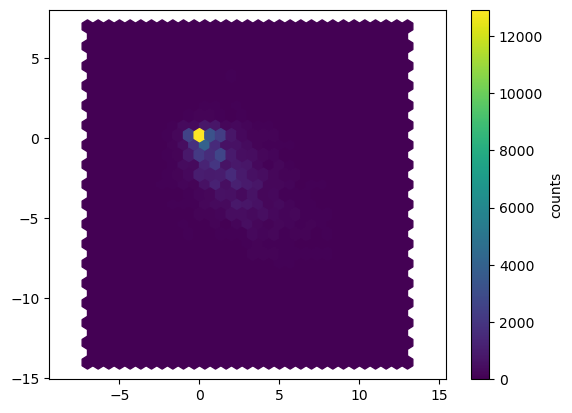

In [ ]:
# Trajectory density plot - shows where particles spend most of their time. can change gridsize for more/less resolution.
plt.hexbin(traj_rel["x_rel"], traj_rel["y_rel"], gridsize=30)
plt.colorbar(label="counts")
plt.axis("equal")
plt.show()

alpha: 0.0025


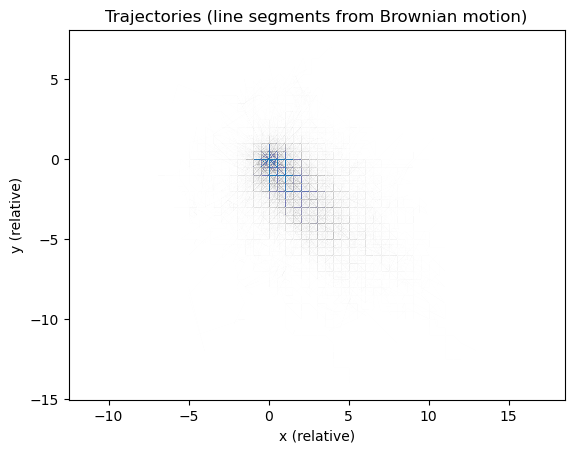

alpha: 0.005


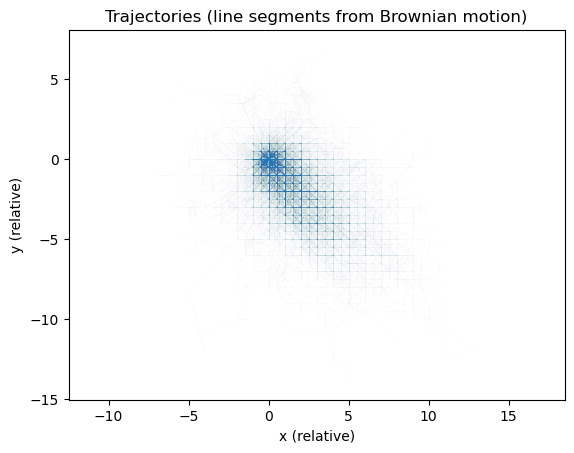

alpha: 0.0075


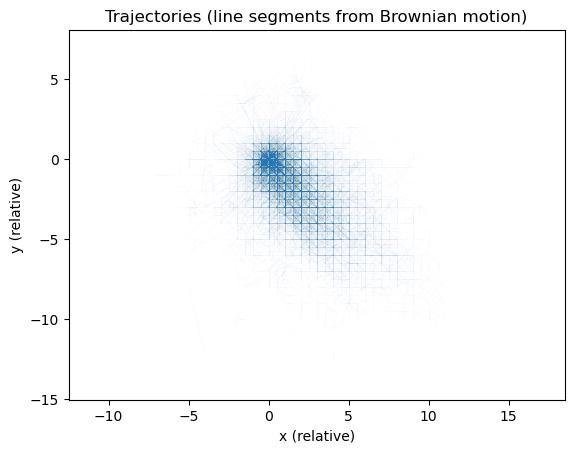

alpha: 0.01


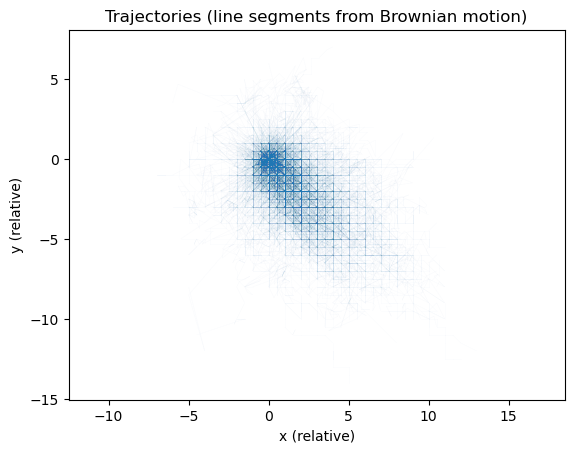

alpha: 0.0125


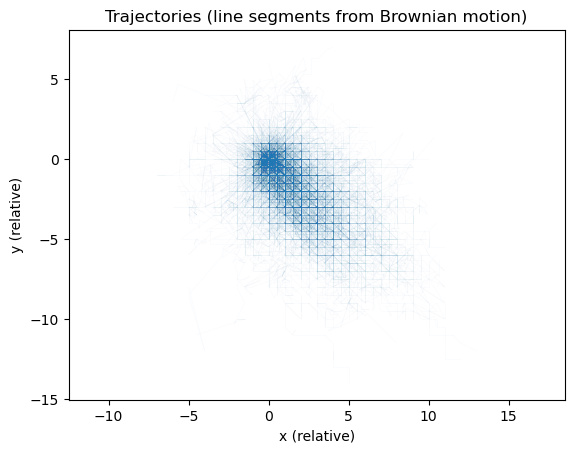

In [ ]:
# Line segment plot with LineCollection and alpha blending


for i in range(5):

    plt.figure()

    segments = []
    plt.grid(False)
    for pid, group in traj_rel.groupby("particle"):
        # pid is particle id 
        group = group.sort_values("frame")
        x = group["x_rel"].values
        y = group["y_rel"].values
        # only create segments if we have at least 2 points
        if len(x) < 2:
            continue
            # create line segments between consecutive points
        pts = np.column_stack([x, y])
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        segments.append(segs)
    # concatenate all segments into a single array for LineCollection
    segments = np.concatenate(segments)
    
    ### PLOTS

    lc = LineCollection(segments, linewidths=0.5, alpha=(i+1)/200)
    print(f"alpha: {(i+1)/400}")
    plt.gca().add_collection(lc)

    plt.xlabel("x (relative)")
    plt.ylabel("y (relative)")
    plt.title("Trajectories (line segments from Brownian motion)")
    plt.axis("equal")
    plt.show()  

In [70]:
dx = trajectories.groupby("particle")["x"].diff()
dy = trajectories.groupby("particle")["y"].diff()

In [71]:
disp = np.sqrt(dx**2 + dy**2)
print(disp.describe())

count    82650.000000
mean         0.303140
std          0.459457
min          0.000000
25%          0.000000
50%          0.000000
75%          0.500000
max          5.000000
dtype: float64
